In [137]:
# ============================================================================
# OPTIMIZED FRB SIMULATION: DETECT 10 FRBs PER REDSHIFT BIN
# ============================================================================
# Strategy:
# 1. For each redshift bin, generate FRBs one-by-one
# 2. Sample luminosity from TRUNCATED Schechter function (L_min to L_max)
# 3. Detect when possible, count until 10 detections
# 4. Scale results back up using luminosity ratios and SFR
# ============================================================================

In [138]:

from pathlib import Path
import time
import numpy as np
from astropy.cosmology import Planck18 as cosmo
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad, simps, cumtrapz  # ADD cumtrapz HERE
from scipy.optimize import curve_fit
from scipy.special import erf
import sympy as sp
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches
from astropy.cosmology import Planck18, z_at_value
from astropy import units as u
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM

In [139]:
# ============================================================================
# TELESCOPE SELECTION
# ============================================================================
TELESCOPE = "FAST"
# Other options: "Fast", "Meerkat_incoherent", "Meerkat_coherent", "askap_ics", "askap_flyeye"

TELESCOPE_PARAMS = {
    "parkes": {
        "D": 64,
        "eta": 0.6,
        "Trec": 25,
        "Tsky": 3,
        "BW": 340e6,
        "nu_cen": 1.382e9,
        "n_comp": 16,
        "n_dishes": 1,
        "n_chan": int(1024*340/400),
        "mode": "multibeam",
        "n_beams": 13,
        "tsamp": 0.064,
        "fov": 0.56,
    },
    "fast": {
        "D": 300,
        "eta": 0.6,
        "Trec": 24,
        "Tsky": 3,
        "BW": 500e6,
        "nu_cen": 1.25e9,
        "n_chan": 2048,
        "n_comp": 8,
        "n_dishes": 1,
        "mode": "multibeam",
        "n_beams": 19,
        "tsamp": 196.608e-6,
        "fov": 0.061,
    },
    "meerkat_incoherent": {
        "D": 13.5,
        "eta": 0.70,
        "Trec": 20,
        "Tsky": 3,
        "BW": 856e6,
        "nu_cen": 1.284e9,
        "n_comp": 16,
        "n_dishes": 64,
        "n_chan": 2048,
        "mode": "incoherent",
        "description": "MeerKAT array - incoherent beam (power addition)",
        "tsamp": 306.24e-6,
        "fov": 1.27,
    },
    "meerkat_coherent": {
        "D": 13.5,
        "eta": 0.70,
        "Trec": 20,
        "Tsky": 3,
        "BW": 856e6,
        "nu_cen": 1.284e9,
        "n_comp": 16,
        "n_dishes": 40,
        "n_chan": 2048,
        "mode": "coherent",
        "description": "MeerKAT array - coherent beam (phase alignment)",
        "tsamp": 306.24e-6,
        "fov": 0.4,
    },
    "askap_ics": {
        "D": 12,
        "eta": 0.6,
        "Trec": 70,
        "Tsky": 3,
        "BW": 336e6,
        "nu_cen": 1.32e9,
        "n_comp": 16,
        "n_dishes": 36,
        "n_chan": 2048,
        "mode": "incoherent",
        "description": "ASKAP array - Incoherent configuration",
        "tsamp": 1.265e-3,
        "fov": 20,
    },
    "askap_flyeye": {
        "D": 12,
        "eta": 0.6,
        "Trec": 70,
        "Tsky": 3,
        "BW": 336e6,
        "nu_cen": 1.32e9,
        "n_comp": 16,
        "n_dishes": 36,
        "n_chan": 2048,
        "mode": "multibeam",
        "description": "ASKAP array - fly's eye configuration",
        "tsamp": 1.265e-3,
        "fov": 160,
    }
}


In [140]:
alpha_intrinsic = 0 # Fixed intrinsic spectral index

In [141]:


# Load selected telescope
if TELESCOPE.lower() not in TELESCOPE_PARAMS:
    raise ValueError(f"Telescope must be one of: {list(TELESCOPE_PARAMS.keys())}")

params = TELESCOPE_PARAMS[TELESCOPE.lower()]

# Physical constants
k = 1.38e-23
c = 3.0e8

# Extract telescope parameters
D = params["D"]
eta = params["eta"]
n_dishes = params.get("n_dishes", 1)
mode = params.get("mode", "single")

n_beams = params.get("n_beams", 1) if mode != "coherent" and mode != "incoherent" else 1


Np = 2
Trec = params["Trec"]
Tsky = params["Tsky"]
BW = params["BW"]
n_comp = params["n_comp"]
BW_comp = BW / n_comp
n_chan = params["n_chan"]
BW_chan = BW / n_chan
nu_cen = params["nu_cen"]
nu_min = nu_cen - BW / 2
nu_max = nu_cen + BW / 2
nu_array = np.linspace(nu_min, nu_max, n_comp+1)

print(f"{'='*100}")
print(f"TELESCOPE: {TELESCOPE}")
print(f"  Diameter: {D} m")
print(f"  Receiver temp: {Trec} K")
print(f"  Bandwidth: {BW/1e6:.0f} MHz at {nu_cen/1e9:.3f} GHz")
print(f"  N_dishes: {n_dishes}, Mode: {mode}")
print(f"  FoV: {params['fov']} deg²")
print(f"{'='*100}\n")


TELESCOPE: FAST
  Diameter: 300 m
  Receiver temp: 24 K
  Bandwidth: 500 MHz at 1.250 GHz
  N_dishes: 1, Mode: multibeam
  FoV: 0.061 deg²



In [142]:

# ============================================================================
# REDSHIFT PARAMETERS
# ============================================================================
dz = 0.01
z_min = 0.01
z_max = 5.0
z_array_opt = np.arange(z_min, z_max, dz)

# Luminosity function parameters
L_STAR = 1e15  # Characteristic luminosity (Jy·kpc²)
ALPHA_SCH = -1.5  # Faint-end slope
L_MIN_SCH = 1e10
L_MAX_SCH = 1e16

# Simulation parameters
theta_max = 2*1.22*c/12/nu_min # please note here
fscale = 0.2 * 1e-7  # FRB rate scaling factor

SNR_threshold = 10
t_obs = 0.001
TARGET_DETECTIONS = 10  # Target 10 detections per z-bin

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
fwhm_rad = 1.22 * (c / nu_min) / D
fwhm_deg = fwhm_rad * (180 / np.pi)
r_deg = 2.0 * fwhm_deg
area = np.pi * (r_deg)**2

# Calculate frequency-dependent scattering term
freq_powers_scatter = np.array([(nu_min * BW_comp * (i+1))**(-4) for i in range(n_comp)])

np.random.seed(42)

print(f"{'='*100}")
print(f"REDSHIFT PARAMETERS")
print(f"  Redshift range: {z_min:.2f} - {z_max:.2f}")
print(f"  Redshift bin width (dz): {dz}")
print(f"  Number of redshift bins: {len(z_array_opt)}")
print(f"  Sky area: {area} deg²")
print(f"{'='*100}\n")

print(f"LUMINOSITY FUNCTION")
print(f"  Model: Schechter")
print(f"  L* = {L_STAR:.2e} Jy·kpc²")
print(f"  α = {ALPHA_SCH}")
print(f"  L_min = {L_MIN_SCH:.2e}, L_max = {L_MAX_SCH:.2e} Jy·kpc²")
print(f"{'='*100}\n")


REDSHIFT PARAMETERS
  Redshift range: 0.01 - 5.00
  Redshift bin width (dz): 0.01
  Number of redshift bins: 499
  Sky area: 0.06140090752363563 deg²

LUMINOSITY FUNCTION
  Model: Schechter
  L* = 1.00e+15 Jy·kpc²
  α = -1.5
  L_min = 1.00e+10, L_max = 1.00e+16 Jy·kpc²



In [143]:
def gaussian_beam_gain(nu, G0, theta, D, c):
    """
    Gaussian beam gain with frequency dependence
    G(ν) = G₀ × exp[−θ²ν²D²×2.355²/(2×1.22²×c²)]

    Returns:
    Gain (K/Jy)
    """
    # Exponent coefficient
    coeff = (theta**2 * D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    return G0 * np.exp(-coeff * nu**2)


def SNR(S,t,G,BW,Np,Trec,Tsky):
    return(S*G*np.sqrt(BW*t*Np)/(Trec+Tsky))

In [144]:
def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Parameters:
    -----------
    L : float or array
        Luminosity
    L_star : float
        Characteristic luminosity (knee of the function)
    alpha : float
        Faint-end slope (typically negative)
    phi_star : float
        Normalization constant (default: 1.0)
    
    Returns:
    --------
    phi : float or array
        Number density at luminosity L
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x)

In [145]:
def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    # REMOVE THIS LINE:
    # from scipy.integrate import cumtrapz
    
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

In [146]:
def get_fast_beam_gains(nu_array):
    """
    Parameters:
    -----------
    nu_array : array
        Frequencies at which to get gains (Hz)

    Returns:
    --------
    G_nu : array
        Gains at the specified frequencies
    """
    # Randomly pick a beam
    random_beam = df_fast_beams.sample(1).iloc[0]

    # Extract gain columns
    gain_columns = [col for col in df_fast_beams.columns if col.startswith('Gain_')]
    G_measured = random_beam[gain_columns].values.astype(float)

    # Extract frequency information from column names (e.g., 'Gain_1050' -> 1050 MHz)
    freqs_measured = np.array([int(col.split('_')[1]) for col in gain_columns]) * 1e6  # Convert MHz to Hz

    # Interpolate to match nu_array
    interp_func = interp1d(freqs_measured, G_measured, kind='linear',
                        bounds_error=False, fill_value='extrapolate')
    G_nu = interp_func(nu_array)

    return np.clip(G_nu, 0, np.max(G_measured))

df_fast_beams = pd.read_csv('FAST_beam_gain.csv')
print(f"Loaded FAST beam data: {df_fast_beams.shape[0]} beams")
print(f"Gain columns: {[col for col in df_fast_beams.columns if col.startswith('Gain_')]}\n")

Loaded FAST beam data: 19 beams
Gain columns: ['Gain_1050', 'Gain_1100', 'Gain_1150', 'Gain_1200', 'Gain_1250', 'Gain_1300', 'Gain_1350', 'Gain_1400', 'Gain_1450']



In [147]:
# ============================================================================
# PRE-CACHE BEAMS FOR DIFFERENT Frequecny
# ============================================================================
# We do this once to avoid calling interp1d inside the simulation loop.
print("Pre-caching FAST beam gains for all frequencies...")

beam_gain_cache = {}
gain_columns = [col for col in df_fast_beams.columns if col.startswith('Gain_')]
freqs_measured = np.array([int(col.split('_')[1]) for col in gain_columns]) * 1e6

for i in range(len(df_fast_beams)):
    G_measured = df_fast_beams.iloc[i][gain_columns].values.astype(float)
    # Create the interpolation function once for this beam
    interp_func = interp1d(freqs_measured, G_measured, kind='linear', 
                        bounds_error=False, fill_value='extrapolate')
    # Cache the gains at our simulation frequencies (nu_array)
    beam_gain_cache[i] = interp_func(nu_array)

print(f"  Done! Cached {len(beam_gain_cache)} beams.")

Pre-caching FAST beam gains for all frequencies...
  Done! Cached 19 beams.


In [148]:
# ============================================================================
# FIXED PRE-COMPUTE FOR FAST
# ============================================================================
print("Pre-computing FAST-specific minimum detectable luminosity...")

# 1. Get the actual peak gain from your FAST beam data
# (Pick one representative beam or the average of all beams)
gain_columns = [col for col in df_fast_beams.columns if col.startswith('Gain_')]
G_max_fast = df_fast_beams[gain_columns].values.max() 

L_min_by_z = {}

for z in z_array_opt:
    dl = cosmo.luminosity_distance(z).value * 1000 # to kpc
    
    # 2. Use the REAL FAST peak gain here
    S_min = SNR_threshold * (Trec + Tsky) / (G_max_fast * np.sqrt(BW * t_obs * Np))
    
    z_factor = (1 + z)**(-1 - alpha_intrinsic)
    L_min = S_min * (dl**2) * z_factor
    
    L_min_by_z[z] = np.clip(L_min, L_MIN_SCH, L_MAX_SCH)

print(f"Done! New FAST L_min at z=1: {L_min_by_z[1.0]:.3e}")

Pre-computing FAST-specific minimum detectable luminosity...
Done! New FAST L_min at z=1: 3.472e+11


In [149]:
# ============================================================================
# OPTIMIZED get_fast_beam_gains - uses cached gains
# ============================================================================
def get_fast_beam_gains_cached(nu_array, theta_frb):
    """
    Get cached beam gains with off-axis attenuation.
    Much faster since gains are pre-computed!
    """
    # Randomly pick from cached beams (instant lookup)
    beam_id = np.random.randint(0, len(beam_gain_cache))
    G_nu = beam_gain_cache[beam_id].copy() # Copy to avoid modifying cache
    # Apply off-axis attenuation
    gain_reduction = np.exp(-(theta_frb**2 * nu_array**2 * D**2) / (2 * 1.22**2 * c**2))
    G_nu = G_nu * gain_reduction

    return G_nu

In [150]:
# Constants for FAST lower band
D = 300           # Telescope diameter (m)
c = 3.0e8         # Speed of light (m/s)
nu_low = 1.05e9   # FAST lower frequency limit (Hz)

# Calculate FWHM in radians
fwhm_rad_low = 1.22 * (c / nu_low) / D

# Convert to degrees and arcminutes
fwhm_deg_low = fwhm_rad_low * (180 / np.pi)
fwhm_arcmin_low = fwhm_deg_low * 60

print(f"FAST Beam FWHM at {nu_low/1e9:.2f} GHz (Lower Band):")
print(f"  Radians:  {fwhm_rad_low:.6f}")
print(f"  Degrees:  {fwhm_deg_low:.4f}°")
print(f"  Arcmin:   {fwhm_arcmin_low:.2f}'")

FAST Beam FWHM at 1.05 GHz (Lower Band):
  Radians:  0.001162
  Degrees:  0.0666°
  Arcmin:   3.99'


In [151]:
# Formula from your notebook:
# theta_max = 2 * 1.22 * c / 12 / nu_min

c = 3.0e8         # Speed of light (m/s)
nu_min = 1.05e9    # FAST lower frequency limit (approx 1000 MHz)

theta_max_rad = 2 * 1.22 * c /D / nu_min
theta_max_deg = theta_max_rad * (180 / np.pi)
theta_max_arcmin = theta_max_deg * 60

print(f"Simulation theta_max (Search Radius):")
print(f"  Radians:  {theta_max_rad:.6f}")
print(f"  Degrees:  {theta_max_deg:.4f}°")
print(f"  Arcmin:   {theta_max_arcmin:.2f}'")

Simulation theta_max (Search Radius):
  Radians:  0.002324
  Degrees:  0.1331°
  Arcmin:   7.99'


In [152]:
# ============================================================================
# PRE-COMPUTE MINIMUM DETECTABLE LUMINOSITY FOR EACH Z
# ============================================================================
print("Pre-computing minimum detectable luminosity (using FAST CSV beam data)...")

# Get the actual peak gain from your FAST beam data
gain_columns = [col for col in df_fast_beams.columns if col.startswith('Gain_')]
G_max_fast = df_fast_beams[gain_columns].values.max()
print(f"  Peak gain from FAST CSV data: {G_max_fast:.4f} K/Jy\n")

L_min_by_z = {}
nu0 = nu_cen

for z in z_array_opt:
    # Luminosity distance
    dl = cosmo.luminosity_distance(z).value * 1000  # Mpc to kpc
    
    # Minimum flux at beam center (using REAL FAST peak gain from CSV)
    S_min = SNR_threshold * (Trec + Tsky) / (G_max_fast * np.sqrt(BW * t_obs * Np))
    
    # Minimum luminosity
    z_factor = (1 + z)**(-1 - alpha_intrinsic)
    L_min = S_min * (dl**2) * z_factor
    
    # Clamp to valid range
    L_min_clamped = np.clip(L_min, L_MIN_SCH, L_MAX_SCH)
    
    L_min_by_z[z] = L_min_clamped

print(f"  Done! L_min range: {min(L_min_by_z.values()):.3e} - {max(L_min_by_z.values()):.3e}\n")

# ============================================================================
# CREATE TRUNCATED SCHECHTER SAMPLER FOR EACH Z
# ============================================================================
print("Creating truncated Schechter samplers...")

def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    from scipy.integrate import cumtrapz
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

sampler_cache = {}
print(f"  Done!\n")

Pre-computing minimum detectable luminosity (using FAST CSV beam data)...
  Peak gain from FAST CSV data: 16.9744 K/Jy

  Done! L_min range: 1.000e+10 - 5.752e+12

Creating truncated Schechter samplers...
  Done!



In [153]:
print (L_min_by_z)

{0.01: 10000000000.0, 0.02: 10000000000.0, 0.03: 10000000000.0, 0.04: 10000000000.0, 0.05: 10000000000.0, 0.060000000000000005: 10000000000.0, 0.06999999999999999: 10000000000.0, 0.08: 10000000000.0, 0.09: 10000000000.0, 0.09999999999999999: 10000000000.0, 0.11: 10000000000.0, 0.12: 10000000000.0, 0.13: 10000000000.0, 0.14: 10000000000.0, 0.15000000000000002: 10000000000.0, 0.16: 10000000000.0, 0.17: 10000000000.0, 0.18000000000000002: 10242383446.234312, 0.19: 11451832944.767643, 0.2: 12732110657.49908, 0.21000000000000002: 14083583695.460627, 0.22: 15506593969.150478, 0.23: 17001458760.602839, 0.24000000000000002: 18568471297.046734, 0.25: 20207901325.32472, 0.26: 21919995686.26544, 0.27: 23704978888.28725, 0.28: 25563053679.466496, 0.29000000000000004: 27494401617.428402, 0.3: 29499183636.377426, 0.31: 31577540610.666496, 0.32: 33729593914.328045, 0.33: 35955445976.00503, 0.34: 38255180828.787796, 0.35000000000000003: 40628864654.47477, 0.36000000000000004: 43076546321.80116, 0.37: 

In [154]:
# ============================================================================
# MAIN SIMULATION LOOP - DETECT 10 FRBs PER Z-BIN
# ============================================================================

results_optimized = []
z_bins_non_detectable = []

start_time = time.time()

print(f"{'='*100}")
print(f"STARTING MAIN SIMULATION: {TELESCOPE}")
print(f"Strategy: Detect {TARGET_DETECTIONS} FRBs per z-bin using cached beams and spatial filtering.")
print(f"{'='*100}\n")

for z_idx, z in enumerate(z_array_opt):
    zmin = z - 0.5 * dz
    zmax = z + 0.5 * dz
    
    L_min_z = L_min_by_z[z]
    
    # 1. Check if z-bin is even reachable
    if L_min_z > 8.952e15:
        print(f"\nZ >= {z:.2f}: L_min ({L_min_z:.2e}) > limit. Stopping simulation.")
        break
    
    # 2. Get/Create luminosity sampler
    if L_min_z not in sampler_cache:
        sampler_cache[L_min_z] = create_truncated_schechter_sampler(
            L_min_z, L_MAX_SCH, L_STAR, ALPHA_SCH
        )
    truncated_sampler = sampler_cache[L_min_z]

    # 3. Pre-compute z-dependent parameters (once per z-bin)
    DM = 1000 * z
    wi_z = 0.001 * (1 + z)
    nu_cen_GHz = nu_cen / 1e9
    BW_chan_MHz = BW_chan / 1e6
    
    # Width components
    w_DM = 8.3e-6 * DM * BW_chan_MHz / (nu_cen_GHz**3)
    w_scatter_comp = 1.9e-7 * (DM**1.5) * (1 + (DM**3) * 3.55e-5) * 3 * freq_powers_scatter * 1e-3
    w_scatter = np.sqrt(np.sum(w_scatter_comp**2) / len(w_scatter_comp))
    w_sampling = 196.608e-6  # CORRECTED FAST sampling time
    
    w_terms_fixed = [wi_z, w_DM, w_scatter, w_sampling]
    w_obs_factor = np.sqrt(np.sum(np.square(w_terms_fixed)))
    
    dl = cosmo.luminosity_distance(z).value * 1000  # to kpc
    z_factor = (1 + z)**(-1 - alpha_intrinsic)

    # 4. Main FRB generation loop
    n_generated = 0
    n_detected = 0
    detected_luminosities = []
    detected_snrs = []
    max_iterations = 1000000

    while n_detected < TARGET_DETECTIONS and n_generated < max_iterations:
        n_generated += 1
        
        # --- SPEED UP: Quick Spatial Filter ---
        theta_frb = theta_max * np.sqrt(np.random.random())
        if theta_frb > (2 * fwhm_rad_low):
            continue  # Skip expensive math for out-of-beam events
            
        # --- REMAINDER OF SIMULATION ---
        lum = float(truncated_sampler(np.random.uniform(0, 1)))
        
        # Calculate flux at reference frequency
        S0_frb = lum / ((dl**2) * z_factor) * (wi_z / w_obs_factor)
        S_nu = S0_frb * (nu_array / nu0)**alpha_intrinsic
        
        # USE CACHED BEAM GAINS (Instant lookup)
        G_nu = get_fast_beam_gains_cached(nu_array, theta_frb)
        
        # Calculate SNR spectrum
        snr_spectrum = SNR(S_nu, t_obs, G_nu, BW_comp, Np, Trec, Tsky)
        snr_coherent = np.sum(snr_spectrum) / np.sqrt(len(snr_spectrum))
        
        if snr_coherent > SNR_threshold:
            n_detected += 1
            detected_luminosities.append(lum)
            detected_snrs.append(snr_coherent)

    # 5. Scaling calculations for population density
    if n_detected == TARGET_DETECTIONS:
        detection_rate = n_detected / n_generated
        
        # Schechter ratio scaling
        L_grid_full = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 5000)
        phi_grid_full = schechter_function(L_grid_full, L_STAR, ALPHA_SCH)
        cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)
        cdf_full = cdf_full / cdf_full[-1]
        cdf_interp_full = interp1d(L_grid_full, cdf_full, kind='linear')
        
        N_ratio = 1.0 - cdf_interp_full(L_min_z)
        
        # Star Formation Rate density (Madau type)
        psi = 0.015 * ((1+z)**2.7) / (1 + ((1+z)/2.9)**5.6)
        
        # Volume and Time
        dt = (cosmo.age(zmin).value - cosmo.age(zmax).value) * 1.e9 #yr
        dvol = (cosmo.comoving_volume(zmax).value - cosmo.comoving_volume(zmin).value) * \
            (area / (4. * np.pi * ((180./np.pi)**2)))
        
        nbeams =19
        nfrb_sfr = psi * dvol * dt * fscale 
        n_total_population = detection_rate * N_ratio * nfrb_sfr * nbeams
        
        results_optimized.append({
            'z': z, 'z_min': zmin, 'z_max': zmax, 'alpha_intrinsic': alpha_intrinsic,
            'L_min': L_min_z, 'n_generated': n_generated, 'n_detected': n_detected,
            'detection_rate': detection_rate, 'mean_SNR': np.mean(detected_snrs),
            'mean_detected_L': np.mean(detected_luminosities), 'N_ratio': N_ratio,
            'psi': psi, 'dvol': dvol, 'dt': dt, 'nfrb_sfr_base': nfrb_sfr,
            'n_total_population': n_total_population
        })
        
        if z_idx % 50 == 0 or z_idx < 10:
            print(f"z={z:.2f}: Generated {n_generated:6d}, Rate {detection_rate:.6f}, n_pop {n_total_population:.1f}")
    else:
        print(f"z={z:.2f}: FAILED - Only {n_detected} detections in {max_iterations} trials")

end_time = time.time()
print(f"\n{'='*100}")
print(f"SIMULATION COMPLETED IN {end_time - start_time:.1f} SECONDS")
print(f"Successfully processed {len(results_optimized)} redshift bins")
print(f"{'='*100}\n")

STARTING MAIN SIMULATION: FAST
Strategy: Detect 10 FRBs per z-bin using cached beams and spatial filtering.

z=0.01: Generated   4546, Rate 0.002200, n_pop 0.0
z=0.02: Generated   7941, Rate 0.001259, n_pop 0.0
z=0.03: Generated   4762, Rate 0.002100, n_pop 0.0
z=0.04: Generated   6977, Rate 0.001433, n_pop 0.0
z=0.05: Generated   7861, Rate 0.001272, n_pop 0.0
z=0.06: Generated   3885, Rate 0.002574, n_pop 0.1
z=0.07: Generated   7961, Rate 0.001256, n_pop 0.1
z=0.08: Generated   6708, Rate 0.001491, n_pop 0.1
z=0.09: Generated   5260, Rate 0.001901, n_pop 0.2
z=0.10: Generated  11218, Rate 0.000891, n_pop 0.1


/tmp/ipykernel_1689649/323940356.py:43: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf = cumtrapz(phi_grid, L_grid, initial=0)
/tmp/ipykernel_1689649/1159107870.py:92: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)


z=0.51: Generated  15770, Rate 0.000634, n_pop 0.6
z=1.01: Generated  12101, Rate 0.000826, n_pop 0.9
z=1.51: Generated  26861, Rate 0.000372, n_pop 0.3
z=2.01: Generated  13025, Rate 0.000768, n_pop 0.4
z=2.51: Generated  16153, Rate 0.000619, n_pop 0.1
z=3.01: Generated  19871, Rate 0.000503, n_pop 0.1
z=3.51: Generated   6687, Rate 0.001495, n_pop 0.1
z=4.01: Generated  10683, Rate 0.000936, n_pop 0.0
z=4.51: Generated  11740, Rate 0.000852, n_pop 0.0

SIMULATION COMPLETED IN 11.2 SECONDS
Successfully processed 499 redshift bins



In [155]:

# ============================================================================
# SAVE RESULTS
# ============================================================================

z_results = np.array([r['z'] for r in results_optimized])
alpha_intrinsic_results = np.array([r['alpha_intrinsic'] for r in results_optimized])
L_min_results = np.array([r['L_min'] for r in results_optimized])
n_generated_results = np.array([r['n_generated'] for r in results_optimized])
n_detected_results = np.array([r['n_detected'] for r in results_optimized])
detection_rate_results = np.array([r['detection_rate'] for r in results_optimized])
# ax = axes[1, 2]
mean_snrs = np.array([r['mean_SNR'] for r in results_optimized])
N_ratio_results = np.array([r['N_ratio'] for r in results_optimized])
n_population_results = np.array([r['n_total_population'] for r in results_optimized])

df_summary = pd.DataFrame({
    'z': z_results,
    'alpha_intrinsic': alpha_intrinsic_results,
    'L_min_Jy_kpc2': L_min_results,
    'L_min_over_L_star': L_min_results / L_STAR,
    'n_generated': n_generated_results,
    'n_detected': n_detected_results,
    'detection_rate_10_per_n': detection_rate_results,
    'N_ratio_detectable_L': N_ratio_results,
    'mean_detected_L': np.array([r['mean_detected_L'] for r in results_optimized]),
    'mean_SNR': np.array([r['mean_SNR'] for r in results_optimized]),
    'SFR_psi': np.array([r['psi'] for r in results_optimized]),
    'comoving_volume_Mpc3': np.array([r['dvol'] for r in results_optimized]),
    'time_Gyr': np.array([r['dt'] for r in results_optimized]),
    'nfrb_sfr_base': np.array([r['nfrb_sfr_base'] for r in results_optimized]),
    'n_total_population_scaled': n_population_results
})

csv_file = f"DM_distribution_new/DM_{TELESCOPE.lower()}_alpha{alpha_intrinsic}_scaled.csv"
df_summary.to_csv(csv_file, index=False)
print(f"Results saved to: {csv_file}\n")

print(f"SUMMARY STATISTICS:")
print(f"  Intrinsic spectral index (α): {alpha_intrinsic}")
print(f"  Redshift range: {z_results.min():.2f} - {z_results.max():.2f}")
print(f"  Total z-bins processed: {len(results_optimized)}")
print(f"  Mean n_generated (per 10 detections): {n_generated_results.mean():.1f}")
print(f"  Min/Max n_generated: {n_generated_results.min():.0f} - {n_generated_results.max():.0f}")
print(f"  Average detection_rate (10/n_gen): {detection_rate_results.mean():.6f}")
print(f"  Average N_ratio (detectable fraction): {N_ratio_results.mean():.6f}")
print(f"  Total population (scaled): {n_population_results.sum():.0f}")
print(f"{'='*100}\n")

Results saved to: DM_distribution_new/DM_fast_alpha0_scaled.csv

SUMMARY STATISTICS:
  Intrinsic spectral index (α): 0
  Redshift range: 0.01 - 4.99
  Total z-bins processed: 499
  Mean n_generated (per 10 detections): 15151.1
  Min/Max n_generated: 3885 - 30252
  Average detection_rate (10/n_gen): 0.000749
  Average N_ratio (detectable fraction): 0.148594
  Total population (scaled): 148



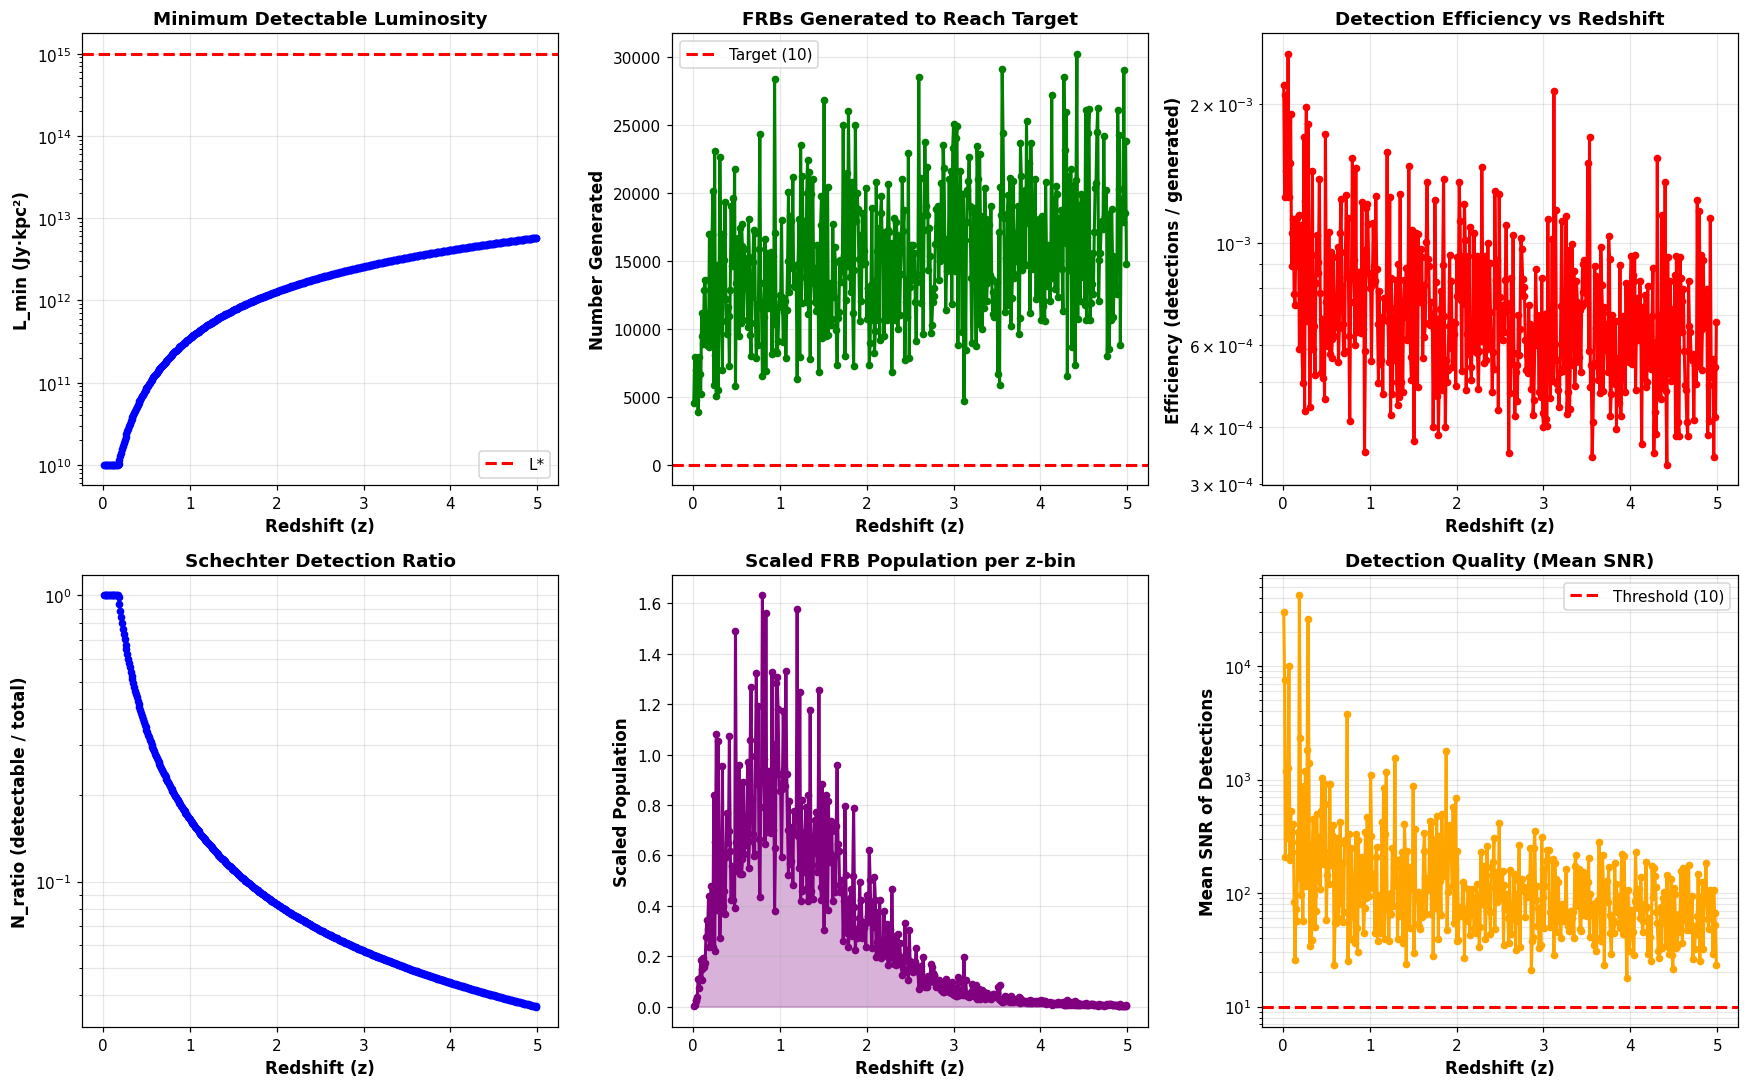


Visualization complete!


In [156]:

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=110)

# Plot 1: L_min vs Redshift
ax = axes[0, 0]
ax.semilogy(z_results, L_min_results, 'b-o', linewidth=2, markersize=4)
ax.axhline(L_STAR, color='red', linestyle='--', linewidth=2, label='L*')
ax.set_xlabel('Redshift (z)', fontsize=11, fontweight='bold')
ax.set_ylabel('L_min (Jy·kpc²)', fontsize=11, fontweight='bold')
ax.set_title('Minimum Detectable Luminosity', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: FRBs Generated vs Redshift
ax = axes[0, 1]
ax.plot(z_results, n_generated_results, 'g-o', linewidth=2, markersize=4)
ax.axhline(TARGET_DETECTIONS, color='red', linestyle='--', linewidth=2, label=f'Target ({TARGET_DETECTIONS})')
ax.set_xlabel('Redshift (z)', fontsize=11, fontweight='bold')
ax.set_ylabel('Number Generated', fontsize=11, fontweight='bold')
ax.set_title('FRBs Generated to Reach Target', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Detection Efficiency
ax = axes[0, 2]
efficiency_results = detection_rate_results
ax.semilogy(z_results, efficiency_results, 'r-o', linewidth=2, markersize=4)
ax.set_xlabel('Redshift (z)', fontsize=11, fontweight='bold')
ax.set_ylabel('Efficiency (detections / generated)', fontsize=11, fontweight='bold')
ax.set_title('Detection Efficiency vs Redshift', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')

# Plot 4: N_ratio vs Redshift
ax = axes[1, 0]
ax.semilogy(z_results, N_ratio_results, 'b-o', linewidth=2, markersize=4)
ax.set_xlabel('Redshift (z)', fontsize=11, fontweight='bold')
ax.set_ylabel('N_ratio (detectable / total)', fontsize=11, fontweight='bold')
ax.set_title('Schechter Detection Ratio', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')

# Plot 5: Population Numbers (Scaled)
ax = axes[1, 1]
ax.plot(z_results, n_population_results, 'purple', marker='o', linewidth=2, markersize=4)
ax.fill_between(z_results, n_population_results, alpha=0.3, color='purple')
ax.set_xlabel('Redshift (z)', fontsize=11, fontweight='bold')
ax.set_ylabel('Scaled Population', fontsize=11, fontweight='bold')
ax.set_title('Scaled FRB Population per z-bin', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 6: Mean SNR of Detections
ax = axes[1, 2]
mean_snrs = np.array([r['mean_SNR'] for r in results_optimized])
ax.semilogy(z_results, mean_snrs, 'orange', marker='o', linewidth=2, markersize=4)
ax.axhline(SNR_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({SNR_threshold})')
ax.set_xlabel('Redshift (z)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean SNR of Detections', fontsize=11, fontweight='bold')
ax.set_title('Detection Quality (Mean SNR)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
# plt.savefig(f'FRB_detection_analysis_{TELESCOPE.lower()}_optimized.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization complete!")